# Hypixel Skyblock - Difference in Differences Analysis

### Exploring the causal effect of marketplace price changes to Hypixel server store on in-game booster cookie prices. 

## Composed Commodity Control Index

In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

sys.path.append(os.path.abspath('..'))
from scripts.market_api import data_pull
from scripts.data_construction import data_construction

# Define the precise API registry endpoints for all major counterfactual assets
missing_gems = {
    'perfect_amber_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_AMBER_GEM/history',
    'perfect_topaz_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_TOPAZ_GEM/history',
    'perfect_sapphire_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_SAPPHIRE_GEM/history',
    'perfect_amethyst_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_AMETHYST_GEM/history',
    'perfect_jasper_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_JASPER_GEM/history',
    'perfect_ruby_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_RUBY_GEM/history',
    'perfect_jade_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_JADE_GEM/history',
    'perfect_opal_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_OPAL_GEM/history',
    'perfect_aquamarine_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_AQUAMARINE_GEM/history',
    'perfect_citrine_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_CITRINE_GEM/history',
    'perfect_onyx_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_ONYX_GEM/history',
    'perfect_peridot_gem': 'https://sky.coflnet.com/api/bazaar/PERFECT_PERIDOT_GEM/history',
}

Executing parallel API data ingestion layer...



In [41]:
print("Executing parallel API data ingestion layer...\n")
period = 230 # 32 Weeks

# Ensure the raw directory exists so data_pull doesn't throw an OS error
os.makedirs("data/raw", exist_ok=True)

for name, url in missing_gems.items():
    # Force the output destination directly into the target data path
    output_path = f"{name}_market_historical.csv"
    
    print(f"Pulling {name.upper()}... Calling data_pull()")
    
    # Run your core ingestion script
    data_pull(url, output_path)

print("\nAll raw CSV matrices successfully downloaded and structured inside data/raw/!")

print("Building Composed Commodity Control Index...\n")

# ----------------- LAYER 1: Core Target (Booster Cookies) -----------------
path_cookie = "data/raw/cookie_market_historical.csv"

cleaned_cookie_data = data_construction(path_cookie).tail(period).reset_index(drop=True)
cleaned_cookie_data['timestamp'] = pd.to_datetime(cleaned_cookie_data['timestamp'])

# ----------------- LAYER 2: Synthetic Control Group Construction -----------------
gem_list = [
    'PERFECT_TOPAZ_GEM', 'PERFECT_RUBY_GEM', 'PERFECT_SAPPHIRE_GEM', 
    'PERFECT_AMBER_GEM', 'PERFECT_JADE_GEM', 'PERFECT_AMETHYST_GEM'
]

gem_data_frames = []

for gem in gem_list:
    # Handle the fact that your Topaz file is saved as 'gemstone_market_historical.csv'
    if gem == 'PERFECT_TOPAZ_GEM':
        path = "data/raw/gemstone_market_historical.csv"
    else:
        path = f"data/raw/{gem.lower()}_market_historical.csv"
        
    if os.path.exists(path):
        df = data_construction(path).tail(period).reset_index(drop=True)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df[['timestamp', 'buy']].rename(columns={'buy': f'buy_{gem}'})
        gem_data_frames.append(df)
    else:
        print(f"Warning: Base data for {gem} not found at {path}. Skipping from index...")

# Merge all available gemstone vectors on exact timestamp alignment
composite_gems = gem_data_frames[0]
for df in gem_data_frames[1:]:
    composite_gems = pd.merge(composite_gems, df, on='timestamp', how='inner')

# Average across columns to isolate pure, market-wide mining sector inflation
buy_cols = [col for col in composite_gems.columns if 'buy_' in col]
composite_gems['buy'] = composite_gems[buy_cols].mean(axis=1)

cleaned_gemstone_data = composite_gems[['timestamp', 'buy']].copy()
print(f"Successfully aggregated {len(buy_cols)} perfect gemstone markets into a single index.")

Executing parallel API data ingestion layer...

Pulling PERFECT_AMBER_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_TOPAZ_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_SAPPHIRE_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_AMETHYST_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_JASPER_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_RUBY_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_JADE_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_OPAL_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_AQUAMARINE_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_CITRINE_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_ONYX_GEM... Calling data_pull()
Success: 500 entries saved.
Pulling PERFECT_PERIDOT_GEM... Calling data_pull()
Success: 500 entries saved.

All raw CSV mat

In [42]:

# ----------------- LAYER 3: Panel Structure Assembly -----------------
cleaned_cookie_data['Treatment'] = 1
cleaned_cookie_data['Asset'] = 'Booster Cookie'

cleaned_gemstone_data['Treatment'] = 0
cleaned_gemstone_data['Asset'] = 'Composite Gemstone Index'

# Stack vectors into long-format panel
panel_df = pd.concat([cleaned_cookie_data, cleaned_gemstone_data], axis=0, ignore_index=True)

# Code policy indicators (Shock: April 15, 2026)
panel_df['Post'] = (panel_df['timestamp'] >= '2026-04-15').astype(int)
panel_df['DiD_Interaction'] = panel_df['Treatment'] * panel_df['Post']
panel_df['log_buy'] = np.log(panel_df['buy'])

# Code linear time trend
min_date = panel_df['timestamp'].min()
panel_df['time_trend'] = (panel_df['timestamp'] - min_date).dt.total_seconds() / (24 * 3600)

print(f"Panel alignment complete. Total panel observations: {len(panel_df)}")

Panel alignment complete. Total panel observations: 460


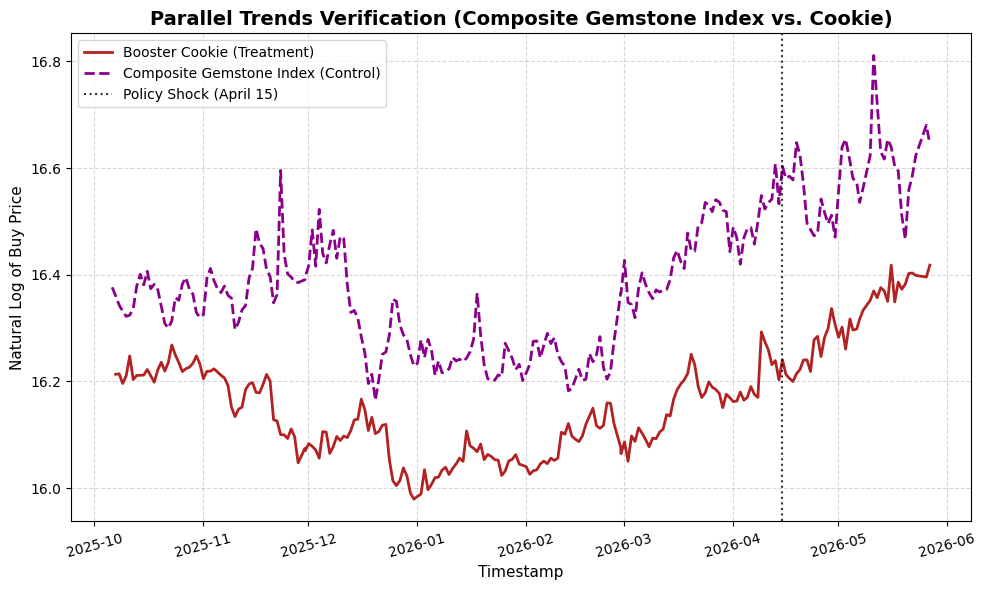


Estimating Fixed Effects Panel Model with Newey-West HAC Standard Errors...
                            OLS Regression Results                            
Dep. Variable:                log_buy   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.725
Method:                 Least Squares   F-statistic:                     129.1
Date:                Thu, 28 May 2026   Prob (F-statistic):           1.40e-73
Time:                        15:24:33   Log-Likelihood:                 482.28
No. Observations:                 460   AIC:                            -954.6
Df Residuals:                     455   BIC:                            -933.9
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

In [ ]:
# ----------------- LAYER 4: Visualization -----------------
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(cleaned_cookie_data['timestamp'], np.log(cleaned_cookie_data['buy']), 
         label='Booster Cookie (Treatment)', color='firebrick', linewidth=2)

ax1.plot(cleaned_gemstone_data['timestamp'], np.log(cleaned_gemstone_data['buy']), 
         label='Composite Gemstone Index (Control)', color='darkmagenta', linewidth=2, linestyle='--')

ax1.axvline(pd.to_datetime('2026-04-15'), color='black', linestyle=':', alpha=0.8, 
            linewidth=1.5, label='Policy Shock (April 15)')

ax1.set_title('Parallel Trends Verification (Composite Gemstone Index vs. Cookie)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Timestamp', fontsize=11)
ax1.set_ylabel('Natural Log of Buy Price', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
# ----------------- LAYER 5: Newey-West Econometric Estimation -----------------
print("\nEstimating Fixed Effects Panel Model with Newey-West HAC Standard Errors...")
model_composite = smf.ols(formula="log_buy ~ Treatment + Post + DiD_Interaction + time_trend", data=panel_df).fit(
    cov_type='HAC', 
    cov_kwds={'maxlags': 4}
)

print(model_composite.summary())